In [34]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score,  classification_report

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
# Загрузка эмбеддингов
embeddings = np.load('embs_3.npy')

In [4]:
# Загрузка патентов
families_df = pd.read_csv('dataset_3_families.csv')
families_df = families_df.dropna()
families_df.app_date = pd.to_datetime(families_df.app_date)
families_df['main_cpc_fam'] = families_df['main_cpc'].apply(lambda code: code.split()[0])

families_df

,app_number,app_date,main_cpc,title,ipc_codes,cpc_codes,main_cpc_fam
0,US18036115,2020-11-09,H04L 41/0897,Geographic scaling in a container based cloud ...,"['H04L 67/52', 'H04L 41/0897', 'H04L 41/5025',...","['H04L 41/0897', 'H04L 43/0852', 'H04L 41/5025...",H04L
1,US14120297,2014-05-14,H01L 33/50,Phosphor-converted light emitting device,"['H01L 33/00', 'H01L 33/50', 'H01L 33/44']","['H01L 33/44', 'H01L 33/50']",H01L
2,US14156168,2014-01-15,H04L 41/0668,Systems and methods for improved fault toleran...,"['H04L 12/703', 'H04L 12/24', 'H04L 29/08', 'H...","['H04L 41/0836', 'H04L 67/1097', 'H04L 67/1034...",H04L
3,US14156196,2014-01-15,G06F 11/0793,System file repair method and apparatus,"['G06F 11/00', 'G06F 11/14', 'G06F 11/07']","['G06F 11/1469', 'G06F 11/0793']",G06F
4,US14156715,2014-01-16,G06F 3/04883,Adjusting values of a plurality of conditions,"['G06F 3/01', 'G06F 3/0488', 'G06F 3/0484']","['G06F 2203/04808', 'G06F 3/04847', 'G06F 3/04...",G06F
...,...,...,...,...,...,...,...
777604,US14175667,2014-02-07,G06F 17/30867,Recursive unique user metrics in real time,['G06F 17/30'],['G06F 17/30867'],G06F
777605,US14176934,2014-02-10,H04L 41/0813,Enhanced throttle management system,"['G06F 15/177', 'H04L 12/24']",['H04L 41/0813'],H04L
777606,US14176997,2014-02-10,G06F 16/951,System and method for generating and interacti...,"['G06F 16/2457', 'G06F 16/951', 'G06F 16/9038'...","['G06F 16/951', 'G06F 16/24575', 'G06F 16/2453...",G06F
777607,US14177324,2014-02-11,G06F 3/041,Electronic device and touch sensing method the...,['G06F 3/041'],"['G06F 3/0416', 'G06F 3/041']",G06F


In [37]:
families_df.app_date.min()

Timestamp('2014-01-02 00:00:00')

In [5]:
families_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777462 entries, 0 to 777608
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   app_number    777462 non-null  object        
 1   app_date      777462 non-null  datetime64[ns]
 2   main_cpc      777462 non-null  object        
 3   title         777462 non-null  object        
 4   ipc_codes     777462 non-null  object        
 5   cpc_codes     777462 non-null  object        
 6   main_cpc_fam  777462 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 47.5+ MB


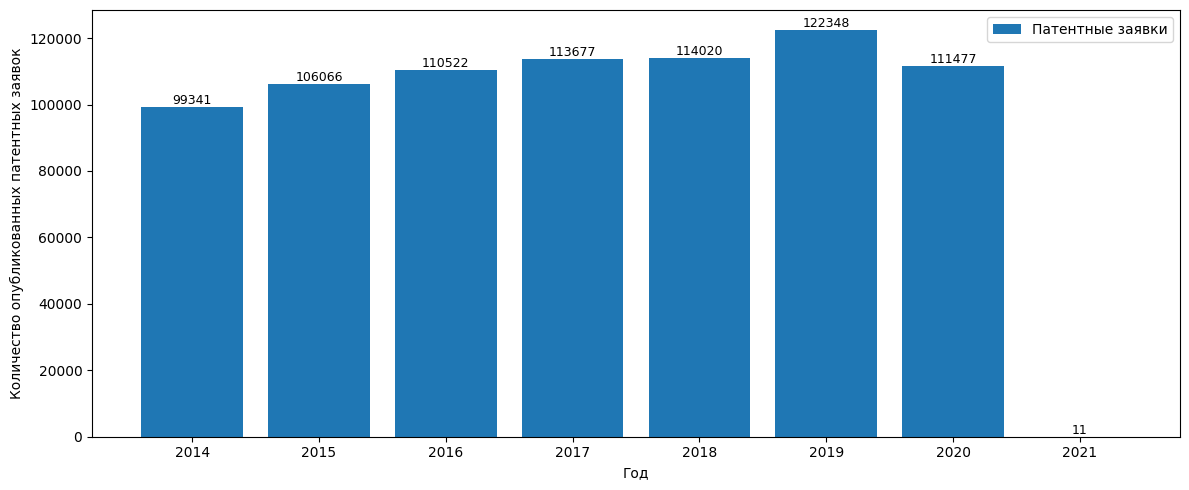

In [6]:
# Распределение патентных заявок по годам

year_counts = (
    families_df.dropna(subset=["app_date"])
    .assign(year=lambda d: d["app_date"].dt.year)
    .groupby("year")
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 5))
bars = plt.bar(year_counts.index, year_counts.values, label="Патентные заявки")

plt.xlabel("Год")
plt.ylabel("Количество опубликованных патентных заявок")
plt.legend()

for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Поиск низкоразмерной структуры

In [7]:
# Выборка патентов за указанный период
samples_patents = families_df[families_df['app_date'] > '2020-01-01']

samples_idx = samples_patents.index.values
samples_embs = embeddings[samples_idx]

samples_patents

,app_number,app_date,main_cpc,title,ipc_codes,cpc_codes,main_cpc_fam
0,US18036115,2020-11-09,H04L 41/0897,Geographic scaling in a container based cloud ...,"['H04L 67/52', 'H04L 41/0897', 'H04L 41/5025',...","['H04L 41/0897', 'H04L 43/0852', 'H04L 41/5025...",H04L
20,US18043761,2020-09-04,G06F 3/04886,Application management apparatus and controlli...,"['G06F 3/04886', 'G06F 3/04817', 'G06F 3/0486']","['G06F 3/04817', 'G06F 3/0486', 'G06F 3/04886']",G06F
1402,US15733878,2020-02-25,H04L 43/0852,"Network delay control method and apparatus, el...","['H04L 43/0852', 'H04L 47/11']","['H04L 47/11', 'H04L 43/0852']",H04L
1547,US15929493,2020-05-05,H01L 21/67184,Front surface and back surface orientation det...,"['H01L 21/67', 'H01L 21/68']","['H01L 21/67294', 'H01L 21/67184', 'H01L 21/67...",H01L
1548,US15929822,2020-05-22,G06Q 10/109,"System and method for a single, unified commun...","['G06F 16/9535', 'G06F 16/958', 'G06F 16/901',...","['G06F 16/958', 'G06Q 10/109', 'G06F 16/9535',...",G06Q
...,...,...,...,...,...,...,...
777549,US17783530,2020-11-20,G06F 8/65,Vehicle control device and program management ...,"['G06F 8/65', 'G06F 9/445', 'B60R 16/02', 'G06...","['B60R 16/02', 'G06F 9/445', 'G06F 8/65', 'G06...",G06F
777550,US17787509,2020-10-13,H04L 9/3265,Zero-knowledge proof-based certificate service...,"['H04L 9/32', 'H04L 9/00']","['H04L 9/3218', 'H04L 9/50', 'H04L 9/3265']",H04L
777551,US17787542,2020-12-09,H04L 43/091,Reporting service for dynamic status informati...,"['H04L 43/091', 'H04L 43/065']","['H04L 43/065', 'H04L 43/091']",H04L
777552,US17788438,2020-12-18,H10K 59/122,"Functional panel, display device, input/output...","['H10K 59/122', 'H01L 23/00', 'H10K 50/852', '...","['G09G 2320/0209', 'H10K 59/122', 'H01L 24/32'...",H10K


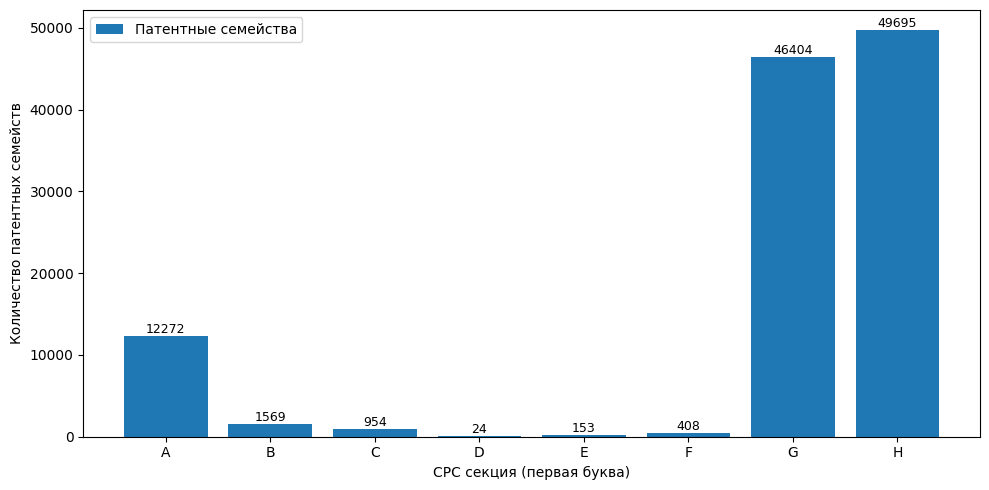

In [8]:
# Распределение глобальных семейств CPC
cpc_sections = samples_patents["main_cpc_fam"].apply(lambda cpc_fam: cpc_fam[0])

sec_counts = cpc_sections.value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(sec_counts.index, sec_counts.values, label="Патентные семейства")

plt.xlabel("CPC секция (первая буква)")
plt.ylabel("Количество патентных семейств")
plt.legend()

for x, y in zip(sec_counts.index, sec_counts.values):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
std_scaler = StandardScaler()
samples_embs_scaled = std_scaler.fit_transform(samples_embs)

In [10]:
# Обработка стандартизированных эмбеддингов PCA
PCA_N_COMPONENTS = 768

pca_full = PCA(n_components=PCA_N_COMPONENTS, random_state=42)
pca_embs = pca_full.fit_transform(samples_embs_scaled)

In [11]:
# Подсчёт накопленной объяснённой дисперсии
explained_var = pca_full.explained_variance_ratio_
cumulative_explained_var = np.cumsum(explained_var)

In [12]:
# Нахождение пороговых значений числа компонент PCA для объяснения заданной доли дисперсии
TARGET_EXPLAINED_VAR = [0.5, 0.75, 0.85, 0.9]

n_target_components = {}
for explained_var_threshold in TARGET_EXPLAINED_VAR:
    n_comps = int(np.searchsorted(cumulative_explained_var, explained_var_threshold) + 1)
    n_target_components[explained_var_threshold] = min(n_comps, PCA_N_COMPONENTS)

/tmp/ipykernel_399411/2861097807.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


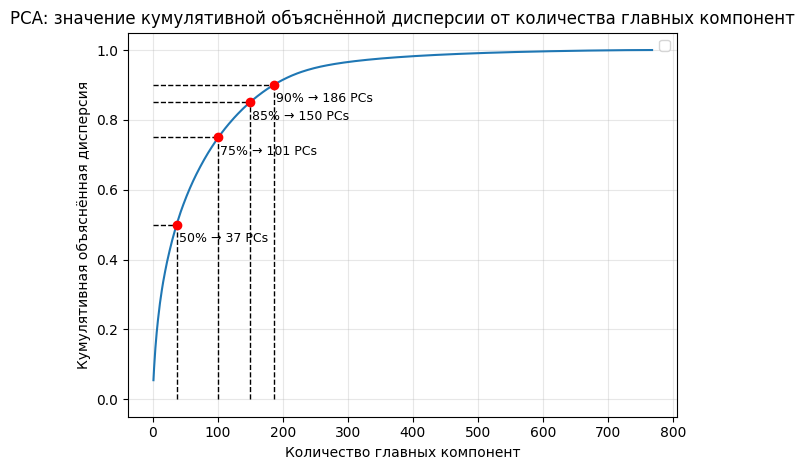

In [13]:
# Построения графика накопленной объяснённой дисперсии
plt.plot(range(1, len(cumulative_explained_var) + 1), cumulative_explained_var, linewidth=1.5)

# Отметка порогов
for explained_var_threshold in TARGET_EXPLAINED_VAR:
    n_components = n_target_components[explained_var_threshold]
    plt.vlines(x=n_components, ymin=0, ymax=explained_var_threshold, colors="black", linestyles="--", linewidth=1)
    plt.hlines(y=explained_var_threshold, xmin=0, xmax=n_components, colors="black", linestyles="--", linewidth=1)
    plt.scatter(n_components, explained_var_threshold, color="red", zorder=3)

    # Аннотация
    plt.text(n_components + 3, explained_var_threshold - 0.05, f"{explained_var_threshold:.0%} → {n_components} PCs", fontsize=9)

plt.xlabel("Количество главных компонент")
plt.ylabel("Кумулятивная объяснённая дисперсия")
plt.title("PCA: значение кумулятивной объяснённой дисперсии от количества главных компонент")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
samples_H_patents = samples_patents[samples_patents['main_cpc_fam'].map(lambda cpc_fam: cpc_fam[0] == 'H')]
samples_H_idx = samples_H_patents.index.values
samples_H_embs = embeddings[samples_H_idx]

samples_H_embs_scaled = std_scaler.fit_transform(samples_H_embs)

In [15]:
samples_H_patents

,app_number,app_date,main_cpc,title,ipc_codes,cpc_codes,main_cpc_fam
0,US18036115,2020-11-09,H04L 41/0897,Geographic scaling in a container based cloud ...,"['H04L 67/52', 'H04L 41/0897', 'H04L 41/5025',...","['H04L 41/0897', 'H04L 43/0852', 'H04L 41/5025...",H04L
1402,US15733878,2020-02-25,H04L 43/0852,"Network delay control method and apparatus, el...","['H04L 43/0852', 'H04L 47/11']","['H04L 47/11', 'H04L 43/0852']",H04L
1547,US15929493,2020-05-05,H01L 21/67184,Front surface and back surface orientation det...,"['H01L 21/67', 'H01L 21/68']","['H01L 21/67294', 'H01L 21/67184', 'H01L 21/67...",H01L
1551,US15930182,2020-05-12,H01L 31/188,Tiled solar module repair process,"['H01L 31/18', 'H01L 31/044', 'H01L 31/02', 'H...","['H01L 31/0504', 'H02S 40/44', 'H01L 31/188', ...",H01L
1555,US15931590,2020-05-14,H04L 9/3247,Authentication system,"['H04L 9/06', 'H04L 9/32', 'H04W 12/06', 'H04L...","['H04L 67/2852', 'G06F 8/65', 'H04L 9/0656', '...",H04L
...,...,...,...,...,...,...,...
777541,US18003895,2020-07-31,H04W 36/085,"Beam switching method and apparatus, and netwo...","['H04L 5/00', 'H04W 36/08', 'H04L 27/28', 'H04...","['H04W 36/085', 'H04L 5/0048', 'H04B 7/0408']",H04W
777550,US17787509,2020-10-13,H04L 9/3265,Zero-knowledge proof-based certificate service...,"['H04L 9/32', 'H04L 9/00']","['H04L 9/3218', 'H04L 9/50', 'H04L 9/3265']",H04L
777551,US17787542,2020-12-09,H04L 43/091,Reporting service for dynamic status informati...,"['H04L 43/091', 'H04L 43/065']","['H04L 43/065', 'H04L 43/091']",H04L
777552,US17788438,2020-12-18,H10K 59/122,"Functional panel, display device, input/output...","['H10K 59/122', 'H01L 23/00', 'H10K 50/852', '...","['G09G 2320/0209', 'H10K 59/122', 'H01L 24/32'...",H10K


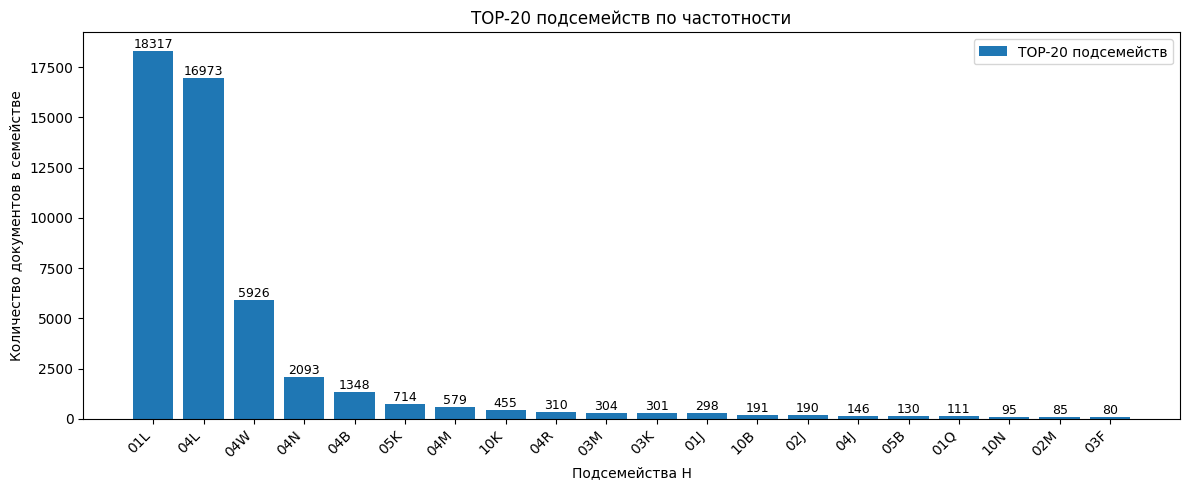

In [38]:
TOP_K = 20

fam = samples_H_patents["main_cpc_fam"].map(lambda cpc_fam: cpc_fam[1:])

top_counts = fam.value_counts().head(TOP_K)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_counts.index.astype(str), top_counts.values, label=f"TOP-{TOP_K} подсемейств")

plt.xlabel("Подсемействa H")
plt.ylabel("Количество документов в семействе")
plt.title(f"TOP-{TOP_K} подсемейств по частотности")
plt.legend()

# подписи количества над столбиками
for x, y in zip(top_counts.index.astype(str), top_counts.values):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


30
t-SNE shape: (49695, 2) | perplexity: 30


/tmp/ipykernel_3375389/2376808832.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("tab20", C)


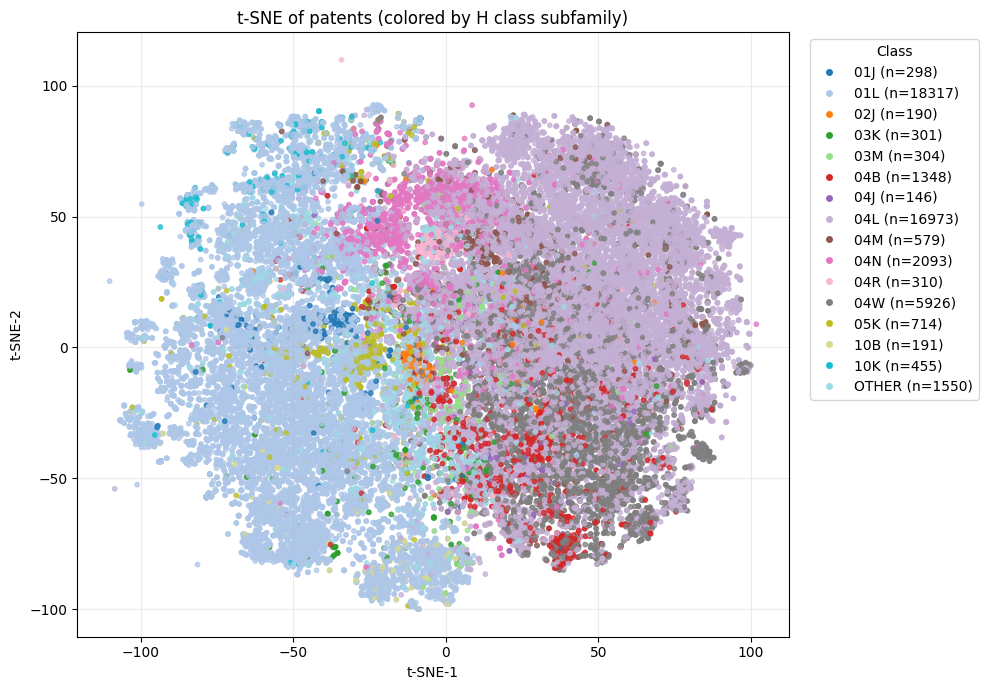

In [140]:
K_PCA = 186
pca = PCA(n_components=K_PCA, random_state=42)
pca_embs = pca.fit_transform(samples_H_embs_scaled)

TOP_K = 15
fam = samples_H_patents["main_cpc_fam"].map(lambda cpc_fam: cpc_fam[1:])

top_fams = fam.value_counts().head(TOP_K).index
fam_plot = fam.where(fam.isin(top_fams), other="OTHER")

le = LabelEncoder()
y = le.fit_transform(fam_plot)
classes = le.classes_


N = pca_embs.shape[0]
perplexity = min(30, max(5, (N // 100)))
perplexity = min(perplexity, (N - 1) / 3)
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

tsne_2d = tsne.fit_transform(pca_embs.astype(np.float32))
print("t-SNE shape:", tsne_2d.shape, "| perplexity:", perplexity)

# Визуализация результатов обработки данных алгоритмом t-SNE
C = len(classes)

# Настройка цветовой карты
base = plt.cm.get_cmap("tab20", C)          
cmap = ListedColormap(base(np.arange(C)))  
norm = BoundaryNorm(np.arange(C+1) - 0.5, C)

plt.figure(figsize=(10, 7))
sc = plt.scatter(
    tsne_2d[:, 0], tsne_2d[:, 1],
    c=y, cmap=cmap, norm=norm,
    s=10, alpha=0.75
)

plt.title("t-SNE of patents (colored by H class subfamily)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.grid(alpha=0.25)

# Формируем легенду карты
counts = np.bincount(y, minlength=C)
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=cmap(i), markeredgecolor='none',
               markersize=5, label=f"{classes[i]} (n={counts[i]})")
    for i in range(C)
]
plt.legend(handles=handles, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3375389/1427213693.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(MAX_PER_CLASS, len(g)), random_state=RANDOM_STATE))


Selected N: 13337 | classes: 20
t-SNE shape: (13337, 2) | perplexity: 30.0


/tmp/ipykernel_3375389/1427213693.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("tab20", C)


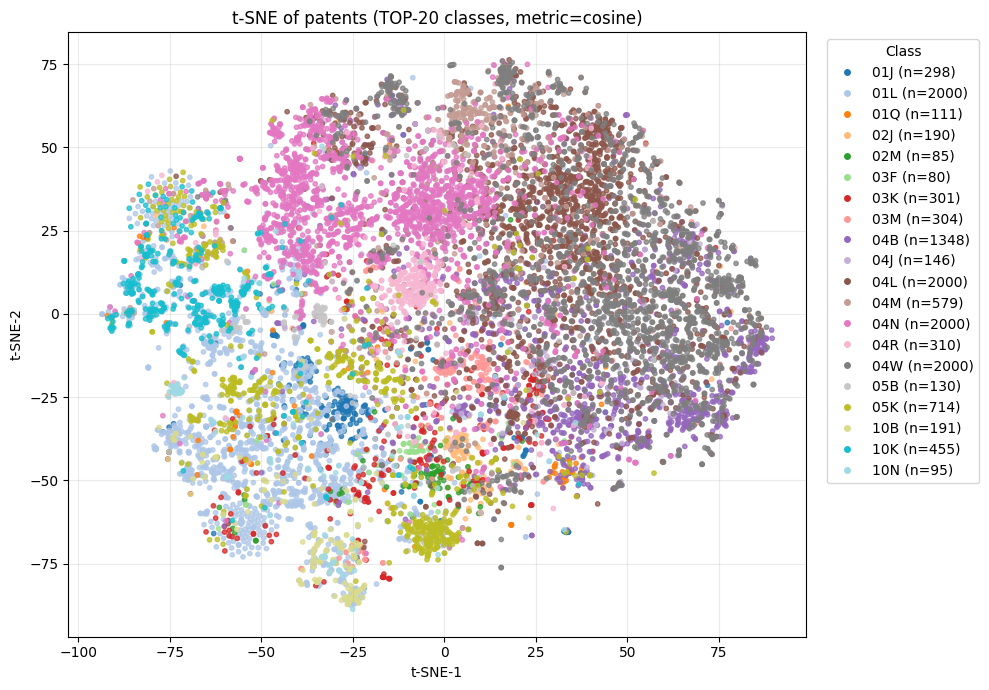

In [144]:
TOP_CLASSES = 20
MAX_PER_CLASS = 2000
RANDOM_STATE = 42

top20 = fam.value_counts().head(TOP_CLASSES).index

df_idx = pd.DataFrame({"fam": fam.values, "idx": np.arange(len(fam))})
df_top = df_idx[df_idx["fam"].isin(top20)]

sampled = (
    df_top.groupby("fam", group_keys=False)
          .apply(lambda g: g.sample(n=min(MAX_PER_CLASS, len(g)), random_state=RANDOM_STATE))
)

sel_idx = sampled["idx"].to_numpy()

X_sub = pca_embs[sel_idx]
fam_sub = fam.iloc[sel_idx].reset_index(drop=True)

print("Selected N:", X_sub.shape[0], "| classes:", fam_sub.nunique())

X_sub = normalize(X_sub)

# Кодировка классов
le = LabelEncoder()
y = le.fit_transform(fam_sub)
classes = le.classes_
C = len(classes)
counts = np.bincount(y, minlength=C)

N = X_pca.shape[0]
perplexity = min(30, max(5, N // 100))
perplexity = min(perplexity, (N - 1) / 3)
perplexity = float(perplexity)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    metric="cosine",
    random_state=RANDOM_STATE,
)
tsne_2d = tsne.fit_transform(X_sub)

print("t-SNE shape:", tsne_2d.shape, "| perplexity:", perplexity)

# Визуализация
base = plt.cm.get_cmap("tab20", C)
cmap = ListedColormap(base(np.arange(C)))
norm = BoundaryNorm(np.arange(C + 1) - 0.5, C)

plt.figure(figsize=(10, 7))
plt.scatter(
    tsne_2d[:, 0], tsne_2d[:, 1],
    c=y, cmap=cmap, norm=norm,
    s=10, alpha=0.75
)

plt.title("t-SNE of patents (TOP-20 classes, metric=cosine)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.grid(alpha=0.25)

# Легенда с количеством
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=cmap(i), markeredgecolor='none',
               markersize=5, label=f"{classes[i]} (n={counts[i]})")
    for i in range(C)
]
plt.legend(handles=handles, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [32]:
TOP_K = 15
fam = samples_H_patents["main_cpc_fam"].map(lambda cpc_fam: cpc_fam[1:])

top_fams = fam.value_counts().head(TOP_K).index
mask = fam.isin(top_fams)

X = samples_H_embs_scaled[mask]
fam_top = fam[mask].astype(str).to_numpy() 

le = LabelEncoder()
y_labels = le.fit_transform(fam_top)         
classes = le.classes_

print("X:", X.shape, "y_labels:", y_labels.shape, "num_classes:", len(classes))

X: (48145, 768) y_labels: (48145,) num_classes: 15


In [17]:
K_PCA = 186
pca = PCA(n_components=K_PCA, random_state=42)
X_pca = pca.fit_transform(X)


In [19]:
def topk_accuracy(knn, X_train, y_train, X_test, y_test, k=5):
    # обучаем и берём k ближайших соседей
    knn.fit(X_train, y_train)
    neigh_ind = knn.kneighbors(X_test, n_neighbors=k, return_distance=False)
    # у KNN в sklearn: обучающие объекты = X_train
    y_train_arr = np.asarray(y_train)
    topk_preds = y_train_arr[neigh_ind]  # (n_test, k)
    return np.mean([y_test[i] in topk_preds[i] for i in range(len(y_test))])

def eval_knn(X_feat, y, n_neighbors=15, metric="cosine", n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, f1s, top5s = [], [], []

    for train_idx, test_idx in skf.split(X_feat, y):
        X_tr, X_te = X_feat[train_idx], X_feat[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        knn = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            metric=metric,
            weights="distance"
        )
        knn.fit(X_tr, y_tr)
        y_pred = knn.predict(X_te)

        accs.append(accuracy_score(y_te, y_pred))
        f1s.append(f1_score(y_te, y_pred, average="macro"))
        top5s.append(topk_accuracy(knn, X_tr, y_tr, X_te, y_te, k=5))

    return {
        "acc_mean": float(np.mean(accs)),
        "acc_std": float(np.std(accs)),
        "macro_f1_mean": float(np.mean(f1s)),
        "macro_f1_std": float(np.std(f1s)),
        "top5_mean": float(np.mean(top5s)),
        "top5_std": float(np.std(top5s)),
    }

res_768 = eval_knn(X, y, n_neighbors=15, metric="cosine")
res_pca = eval_knn(X_pca, y, n_neighbors=15, metric="cosine")

print("kNN on 768:", res_768)
print("kNN on PCA-186:", res_pca)

kNN on 768: {'acc_mean': 0.7919825527053692, 'acc_std': 0.002644480179940076, 'macro_f1_mean': 0.4449335723711452, 'macro_f1_std': 0.007640351252505716, 'top5_mean': 0.9267836743171669, 'top5_std': 0.0014642896859083574}
kNN on PCA-186: {'acc_mean': 0.7909647938519058, 'acc_std': 0.002656200203689914, 'macro_f1_mean': 0.4430626980407334, 'macro_f1_std': 0.0065930606329336235, 'top5_mean': 0.9256620625194725, 'top5_std': 0.0021196179838918116}


In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def print_knn_classification_report(X_feat, y_true, class_names, title,
                                   n_neighbors=15, metric="cosine"):
    X_feat = np.asarray(X_feat)
    y_true = np.asarray(y_true).ravel()

    if X_feat.shape[0] != y_true.shape[0]:
        raise ValueError(f"X and y size mismatch: X={X_feat.shape[0]}, y={y_true.shape[0]}")

    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        weights="distance",
    )

    y_pred = cross_val_predict(knn, X_feat, y_true, cv=cv, n_jobs=-1)

    print("\n" + "="*90)
    print(title)
    print("="*90)
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

print_knn_classification_report(X, y_labels, classes, "kNN (cosine) — 768 dims")
print_knn_classification_report(X_pca, y_labels, classes, "kNN (cosine) — PCA-186")



kNN (cosine) — 768 dims
              precision    recall  f1-score   support

         01J     0.6885    0.2819    0.4000       298
         01L     0.8970    0.9724    0.9332     18317
         02J     0.6577    0.3842    0.4850       190
         03K     0.6833    0.1362    0.2271       301
         03M     0.7267    0.3586    0.4802       304
         04B     0.5478    0.2634    0.3557      1348
         04J     0.5000    0.1096    0.1798       146
         04L     0.7633    0.8691    0.8127     16973
         04M     0.6696    0.2660    0.3807       579
         04N     0.7217    0.4845    0.5798      2093
         04R     0.7188    0.5935    0.6502       310
         04W     0.6003    0.5511    0.5746      5926
         05K     0.6350    0.2997    0.4072       714
         10B     0.1724    0.0262    0.0455       191
         10K     0.3688    0.1143    0.1745       455

    accuracy                         0.7920     48145
   macro avg     0.6234    0.3807    0.4458     48145
w